# Классификация текстов: TF-IDF и логистическая регрессия

В данном ноутбуке продолжается работа начатая [здесь](./bag_of_words_with_logistic_regression.ipynb). Попробуем улучшить модель предсказания характера отзыва заменой Bag of Words на TF-IDF

In [1]:
# Установка зависимостей
!pip install scikit-learn pandas kagglehub seaborn

In [2]:
# Импорт зависимостей
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Загрузка датасета
data_path = kagglehub.dataset_download("ahmedabdulhamid/reviews-dataset")
df = pd.read_csv(f"{data_path}/TestReviews.csv")

# Обновление столбца class
df['isPositive'] = df['class'].astype(bool)
df = df.drop(columns=['class'])

# Тексты отзывов и целевую метку в отдельные переменные.
reviews = df['review']
targets = df['isPositive']

In [4]:
# Подготовка данных для тренировки и тестирования
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(reviews, targets, test_size=0.2, random_state=42)

In [5]:
# Обучение TfidfVectorizer на корпусе.
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.99,
    stop_words='english',
)

X_train = tf_idf.fit_transform(X_train)

In [6]:
# Обучение модели
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
# Трансформация тестовой выборки для удобства работы
X_test = tf_idf.transform(X_test)

In [8]:
# Получение тестовых предсказаний
predictions = model.predict(X_test)

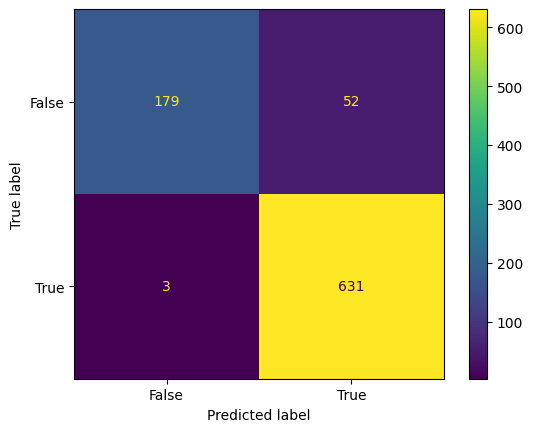

In [9]:
# Матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

На полученной моделе с базовым порогом сразу заметны отличия от такой же модели с применением BoW. Выведем числовые характеристики:

In [10]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Precision: среди всех предсказанных положительных - сколько реально положительные
print(f"Precision: {precision_score(y_test, predictions)}")

# Recall: среди всех реальных положительных - сколько модель нашла
print(f"Recall: {recall_score(y_test, predictions)}")

# F1 Score: баланс между precision и recall (гармоническое среднее)
print(f"F1 Score: {f1_score(y_test, predictions)}")

Precision: 0.9238653001464129
Recall: 0.9952681388012619
F1 Score: 0.9582384206529992


У модели получился явный сдвиг в сторону Recall и поэтому Precision вместе с F1 просели. Найдем лучший порог для этой модели и сравним результаты еще раз

In [11]:
# Коэффициенты уверенности модели в том, что отзыв положительный
prediction_coefs = model.predict_proba(X_test)[:, 1]

In [12]:
# Расчет precision и recall в зависимости от порога (threshold)
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, prediction_coefs)

In [13]:
# Расчет f1 метрики, для выбора самой оптимальной модели
f1 = 2 * (precision * recall) / (precision + recall)

In [14]:
# Получение индекса максимального f1 в расчетах
f1_max_index = f1.argmax()

In [15]:
best_threshold = thresholds[f1_max_index]

In [16]:
# Вывод полученных лучших метрик
print(f"Max F1 score: {f1[f1_max_index]}")
print(f"Max precision: {precision[f1_max_index]}")
print(f"Max recall: {recall[f1_max_index]}")
print(f"Best threshold: {best_threshold}")

Max F1 score: 0.9725058915946582
Max precision: 0.9687010954616588
Max recall: 0.9763406940063092
Best threshold: 0.5970691552782281


In [17]:
# Получение предсказаний с учетом полученного лучшего порога
predictions = model.predict_proba(X_test)[:,1] >= best_threshold

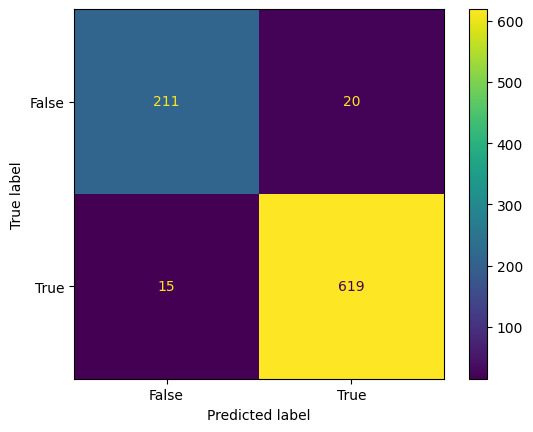

In [18]:
# Матрица ошибок для лучшего порога
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

Применение TF-IDF помогло поднять метрику f1 на 0.01 с 0.96 до 0.97. При этом параметры CountVectorizer и TfidfVectorizer оставлены одинаковыми. Выбор оптимальных параметров поможет дополнительно приблизить f1 метрику к 1